# Классификация интентов в диалогах банковской поддержки

**Задача.** Собрать синтетический датасет диалогов клиента с поддержкой банка и обучить
энкодер-модель определять тему **последней реплики клиента с учётом контекста диалога**.

**План.**
1. Генерация данных открытой LLM (Qwen2.5) с валидацией качества.
2. Классификация, сравнение с бейзлайном и проверка роли контекста (+ сравнение двух классификаторов).


## 0. Настройки

In [1]:
# Движок генерации. vLLM в несколько раз быстрее transformers и позволяет взять модель 7B
USE_VLLM = True

GEN_MODEL = "Qwen/Qwen2.5-7B-Instruct-AWQ" if USE_VLLM else "Qwen/Qwen2.5-3B-Instruct"

N_TRAIN = 25   # диалогов на класс для обучения (минимум по заданию — 20)
N_TEST  = 12   # диалогов на класс для теста   (минимум по заданию — 10)

RUN_RUBERT_BASE = True   # дополнительно обучить ruBert-base для сравнения

In [2]:
!pip -q install -U transformers datasets accelerate scikit-learn

In [ ]:
!pip -q uninstall -y torchaudio

In [32]:
if USE_VLLM:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "vllm"], check=True)
    print("vLLM установлен")

vLLM установлен


In [34]:
import os, re, json, random, gc
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

assert torch.cuda.is_available()
print(torch.cuda.get_device_name(0))

Tesla T4


# Часть 1. Генерация синтетического датасета

## 1.1 Классы

16 классов. Часть из них намеренно близкие по смыслу («статус перевода» / «отмена перевода» /
«комиссия за перевод», «ставки по кредиту» / «ставки по вкладу»), чтобы задача не решалась
по одному ключевому слову.

In [6]:
CLASSES = {
    "transfer_status":      "клиент спрашивает про статус уже отправленного денежного перевода (где деньги, почему не пришли)",
    "transfer_cancel":      "клиент хочет отменить или вернуть уже отправленный перевод",
    "transfer_fee":         "клиент спрашивает про комиссию за перевод (сколько возьмут, как её избежать)",
    "transfer_limits":      "клиент спрашивает про лимиты на переводы (максимальная сумма в день/месяц, как повысить лимит)",
    "card_block":           "клиент хочет заблокировать карту (потерял, украли, подозревает компрометацию)",
    "card_delivery":        "клиент спрашивает про выпуск и доставку новой карты (когда будет готова, куда приедет курьер)",
    "card_pin":             "клиент хочет сменить или восстановить ПИН-код карты",
    "loan_apply":           "клиент хочет оформить кредит или узнать, как подать заявку и какие нужны документы",
    "loan_rates":           "клиент спрашивает про процентные ставки по кредиту",
    "loan_early_repayment": "клиент хочет досрочно погасить кредит полностью или частично",
    "loan_schedule":        "клиент спрашивает про график платежей по кредиту (дата платежа, размер, задолженность)",
    "deposit_open":         "клиент хочет открыть вклад или накопительный счёт",
    "deposit_rates":        "клиент спрашивает про ставки и условия по вкладам",
    "account_statement":    "клиент хочет узнать баланс счёта или получить выписку по операциям",
    "app_issue":            "у клиента технические проблемы с мобильным приложением или входом в интернет-банк",
    "fraud_report":         "клиент сообщает о мошенничестве: с карты списали деньги, звонили «из службы безопасности»",
}
print(len(CLASSES), "классов")

16 классов


## 1.2 Промпты

Два приёма против однообразия и ради соответствия заданию:

- **Персоны клиента** подмешиваются случайно — без них LLM пишет одинаковые диалоги.
  Для train и test используются разные наборы персон, чтобы тест был чуть «другим», чем обучение.
- **Два режима.** В режиме `explicit` последняя реплика клиента сама по себе содержит вопрос.
  В режиме `context` последняя реплика короткая («да, давайте», «и когда?») и понятна только
  из предыдущих реплик — именно этого требует п. 5 задания.

In [7]:
PERSONAS_TRAIN = [
    "вежливый, пишет развёрнуто",
    "торопится, пишет коротко и с опечатками",
    "раздражён, недоволен обслуживанием",
    "пожилой человек, плохо разбирается в приложении",
    "предприниматель, спрашивает по делу",
    "студент, общается неформально",
]
PERSONAS_TEST = [
    "очень тревожный, переспрашивает",
    "пишет строчными буквами и без знаков препинания",
    "деловой тон, короткие сообщения",
    "многословный, рассказывает предысторию",
]

SYSTEM = ("Ты генератор синтетических данных для обучения банковского чат-бота. "
          "Ты пишешь только диалоги в заданном формате, без пояснений и комментариев.")

def build_prompt(label, desc, mode, persona, n=5):
    if mode == "explicit":
        rule = "В последней реплике клиент прямо и понятно формулирует свой вопрос."
    else:
        rule = ("ПЕРВАЯ реплика клиента подробно обозначает тему обращения, оператор отвечает по теме, "
                "и только САМАЯ ПОСЛЕДНЯЯ реплика клиента — короткая уточняющая фраза или согласие "
                "(уточнение срока, суммы, способа из ответа оператора). Она непонятна в отрыве от "
                "диалога, но однозначна вместе с ним. КАЖДЫЙ раз придумывай новую формулировку.")
    return f"""Сгенерируй {n} РАЗНЫХ диалогов клиента с поддержкой банка.

Тема обращения клиента: {desc}
Стиль клиента: {persona}.
{rule}

Правила:
- ровно 3-5 реплик; начинается репликой клиента и ОБЯЗАТЕЛЬНО заканчивается репликой клиента;
- реплики клиента начинаются с "user: ", реплики оператора с "A: ";
- последняя реплика клиента — вопрос или согласие, а НЕ прощание и не благодарность;
- ЗАПРЕЩЕНО заканчивать диалог фразой "а сколько это будет стоить?";
- в диалоге явно звучит тема "{desc}", клиент не перескакивает на другие темы;
- диалоги отличаются формулировками и деталями (суммы, сроки, названия карт, города);
- никаких пояснений, нумерации и markdown.

Формат ответа строго такой:
### ДИАЛОГ
user: ...
A: ...
user: ...
### ДИАЛОГ
user: ...
A: ...
user: ..."""

## 1.3 Разбор ответа модели и валидация

Небольшая LLM часто ломает формат, уходит от темы и заканчивает диалог прощанием. Поэтому
каждый диалог проходит проверку:

1. в тексте звучит тема класса (список ключевых слов);
2. если последняя реплика короткая, тему обязана задавать одна из предыдущих реплик клиента;
3. последняя реплика — вопрос или согласие, а не благодарность;
4. один и тот же вопрос не может принадлежать двум разным классам.

In [8]:
def parse_dialogs(text):
    result = []
    for chunk in re.split(r"#+\s*ДИАЛОГ[^\n]*", text):
        lines = []
        for l in chunk.strip().split("\n"):
            l = re.sub(r"^[\-\*\d\.\)\s]+", "", l.strip())
            low = l.lower()
            if low.startswith(("user:", "клиент:")):
                lines.append("user: " + l.split(":", 1)[1].strip())
            elif low.startswith(("a:", "а:", "оператор:", "поддержка:")):
                lines.append("A: " + l.split(":", 1)[1].strip())
        while lines and lines[-1].startswith("A:"):   # лишний ответ оператора в конце
            lines.pop()
        if len(lines) < 3 or len(lines) > 8:
            continue
        if not lines[0].startswith("user:") or len(lines[-1]) < 9:
            continue
        result.append("\n".join(lines))
    return result


def norm(t):
    return re.sub(r"\W+", " ", t.lower()).strip()


def last_msg(dialog):
    return [l for l in dialog.split("\n") if l.startswith("user:")][-1]


KEYWORDS = {
    "transfer_status":      ["перевод", "перевел", "перевела", "отправ", "поступ", "зачисл", "не пришл", "не дошл"],
    "transfer_cancel":      ["отмен", "вернуть", "возврат", "отозв", "не туда", "ошибочн"],
    "transfer_fee":         ["комисс", "процент", "платно", "бесплатн", "спишут"],
    "transfer_limits":      ["лимит", "ограничен", "максимальн", "сколько можно перевести", "повысить"],
    "card_block":           ["блокир", "потер", "укра", "заморозить"],
    "card_delivery":        ["доставк", "курьер", "выпуск", "заказ", "готова", "отделен"],
    "card_pin":             ["пин", "pin", "пароль от карты"],
    "loan_apply":           ["кредит", "займ", "заявк", "оформить", "документ"],
    "loan_rates":           ["ставк", "процент", "годовых"],
    "loan_early_repayment": ["досрочн", "погас", "погашен", "закрыть кредит", "внести всю"],
    "loan_schedule":        ["график", "платеж", "задолженност", "просроч", "дата списания"],
    "deposit_open":         ["вклад", "накопительн", "депозит", "открыть счет"],
    "deposit_rates":        ["вклад", "ставк", "процент", "доходност"],
    "account_statement":    ["баланс", "выписк", "остаток", "операц", "движение средств"],
    "app_issue":            ["приложен", "войти", "вход", "не работает", "ошибк", "обновлен", "зависа", "не открывается"],
    "fraud_report":         ["мошенн", "списал", "не совершал", "безопасност", "звонил", "подозрительн"],
}

CONFIRM = re.compile(r"^(да|ага|угу|хорошо|ладно|ок|окей|давай|конечно|подтвержд|согласен|понял)", re.I)


def dialog_ok(label, dialog):
    d = dialog.lower().replace("ё", "е")
    if not any(k in d for k in KEYWORDS[label]):
        return False
    users = [l[6:].strip() for l in dialog.split("\n") if l.startswith("user:")]
    if len(users) < 2:
        return False
    last, low = users[-1], users[-1].lower()
    if len(last) < 45 and max(len(u) for u in users[:-1]) < 30:
        return False
    if "спасибо" in low and "?" not in low:
        return False
    return "?" in last or bool(CONFIRM.match(low))

## 1.4 Загрузка модели-генератора

`generate_batch` принимает список промптов и возвращает список ответов — интерфейс одинаковый
для обоих движков.

In [9]:
SAMPLING = dict(temperature=0.95, top_p=0.95)
MAX_NEW_TOKENS = 1200

if USE_VLLM:
    from vllm import LLM, SamplingParams

    llm = LLM(model=GEN_MODEL, dtype="half", max_model_len=4096, gpu_memory_utilization=0.9)
    sampling = SamplingParams(max_tokens=MAX_NEW_TOKENS, **SAMPLING)
    BATCH = 64   # vLLM сам эффективно распараллеливает большие батчи

    def generate_batch(prompts):
        convs = [[{"role": "system", "content": SYSTEM}, {"role": "user", "content": p}] for p in prompts]
        return [o.outputs[0].text for o in llm.chat(convs, sampling, use_tqdm=False)]

else:
    from transformers import AutoTokenizer, AutoModelForCausalLM

    gen_tok = AutoTokenizer.from_pretrained(GEN_MODEL)
    gen_tok.padding_side = "left"
    gen_model = AutoModelForCausalLM.from_pretrained(GEN_MODEL, torch_dtype=torch.float16, device_map="auto").eval()
    BATCH = 8

    @torch.no_grad()
    def generate_batch(prompts):
        chats = [gen_tok.apply_chat_template(
                    [{"role": "system", "content": SYSTEM}, {"role": "user", "content": p}],
                    tokenize=False, add_generation_prompt=True) for p in prompts]
        enc = gen_tok(chats, return_tensors="pt", padding=True).to(gen_model.device)
        out = gen_model.generate(**enc, max_new_tokens=MAX_NEW_TOKENS, do_sample=True,
                                 pad_token_id=gen_tok.pad_token_id or gen_tok.eos_token_id, **SAMPLING)
        return gen_tok.batch_decode(out[:, enc["input_ids"].shape[1]:], skip_special_tokens=True)

print("Генератор:", GEN_MODEL, "| движок:", "vLLM" if USE_VLLM else "transformers")

INFO 09-10 19:02:39 [api_utils.py:286] non-default args: {'dtype': 'half', 'max_model_len': 4096, 'gpu_memory_utilization': 0.9, 'disable_log_stats': True, 'model': 'Qwen/Qwen2.5-7B-Instruct-AWQ'}


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

INFO 09-10 19:03:14 [model.py:684] Resolved architecture: Qwen2ForCausalLM
INFO 09-10 19:03:14 [model.py:2021] Using max model len 4096
INFO 09-10 19:03:15 [scheduler.py:277] Chunked prefill is enabled with max_num_batched_tokens=8192.


model.safetensors.index.json:   0%|          | 0.00/62.7k [00:00<?, ?B/s]

Parse safetensors files:   0%|          | 0/2 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

WARNING 09-10 19:03:24 [system_utils.py:157] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized
INFO 09-10 19:08:55 [hf.py:547] Detected the chat template content format to be 'string'. You can set `--chat-template-content-format` to override this.
Генератор: Qwen/Qwen2.5-7B-Instruct-AWQ | движок: vLLM


## 1.5 Сбор данных

Функция `collect` набирает по `target` диалогов на класс. Множества `seen` и `last_map` общие
для train и test: так в тест не попадут ни дубликаты обучающих диалогов, ни вопросы,
уже занятые другим классом. Дополнительно из теста исключаются диалоги, чья последняя реплика
дословно встречается в train.

In [10]:
DIALOGS_PER_CALL = 5
MAX_ROUNDS = 12

seen = set()
last_map = defaultdict(set)


def collect(target, personas, exclude_lasts=frozenset()):
    pool = {l: [] for l in CLASSES}
    for rnd in range(MAX_ROUNDS):
        todo = [l for l in CLASSES if len(pool[l]) < target]
        if not todo:
            break
        prompts, meta = [], []
        for label in todo:
            for mode in ("explicit", "context"):
                prompts.append(build_prompt(label, CLASSES[label], mode, random.choice(personas), DIALOGS_PER_CALL))
                meta.append(label)

        for i in tqdm(range(0, len(prompts), BATCH), desc=f"раунд {rnd + 1}, классов недобрано {len(todo)}"):
            for label, out in zip(meta[i:i + BATCH], generate_batch(prompts[i:i + BATCH])):
                for d in parse_dialogs(out):
                    if len(pool[label]) >= target:
                        break
                    key, lm = norm(d), last_msg(d)
                    lk = norm(lm)
                    if key in seen or lk in exclude_lasts or not dialog_ok(label, d):
                        continue
                    if "?" in lm and last_map[lk] - {label}:
                        continue
                    last_map[lk].add(label)
                    seen.add(key)
                    pool[label].append(d)
        print({l: len(v) for l, v in pool.items()})
    return pool

In [11]:
print("=== TRAIN ===")
train_pool = collect(N_TRAIN, PERSONAS_TRAIN)

train_lasts = frozenset(norm(last_msg(d)) for ds in train_pool.values() for d in ds)

print("\n=== TEST ===")
test_pool = collect(N_TEST, PERSONAS_TEST, exclude_lasts=train_lasts)

=== TRAIN ===


раунд 1, классов недобрано 16:   0%|          | 0/1 [00:00<?, ?it/s]

{'transfer_status': 0, 'transfer_cancel': 1, 'transfer_fee': 9, 'transfer_limits': 10, 'card_block': 3, 'card_delivery': 9, 'card_pin': 2, 'loan_apply': 2, 'loan_rates': 5, 'loan_early_repayment': 7, 'loan_schedule': 5, 'deposit_open': 5, 'deposit_rates': 9, 'account_statement': 9, 'app_issue': 0, 'fraud_report': 9}


раунд 2, классов недобрано 16:   0%|          | 0/1 [00:00<?, ?it/s]

{'transfer_status': 9, 'transfer_cancel': 7, 'transfer_fee': 15, 'transfer_limits': 16, 'card_block': 3, 'card_delivery': 19, 'card_pin': 9, 'loan_apply': 8, 'loan_rates': 13, 'loan_early_repayment': 14, 'loan_schedule': 13, 'deposit_open': 8, 'deposit_rates': 19, 'account_statement': 19, 'app_issue': 5, 'fraud_report': 13}


...

{'transfer_status': 12, 'transfer_cancel': 12, 'transfer_fee': 12, 'transfer_limits': 12, 'card_block': 7, 'card_delivery': 12, 'card_pin': 12, 'loan_apply': 12, 'loan_rates': 12, 'loan_early_repayment': 12, 'loan_schedule': 12, 'deposit_open': 12, 'deposit_rates': 12, 'account_statement': 12, 'app_issue': 8, 'fraud_report': 12}


раунд 5, классов недобрано 2:   0%|          | 0/1 [00:00<?, ?it/s]

{'transfer_status': 12, 'transfer_cancel': 12, 'transfer_fee': 12, 'transfer_limits': 12, 'card_block': 7, 'card_delivery': 12, 'card_pin': 12, 'loan_apply': 12, 'loan_rates': 12, 'loan_early_repayment': 12, 'loan_schedule': 12, 'deposit_open': 12, 'deposit_rates': 12, 'account_statement': 12, 'app_issue': 8, 'fraud_report': 12}


раунд 6, классов недобрано 2:   0%|          | 0/1 [00:00<?, ?it/s]

{'transfer_status': 12, 'transfer_cancel': 12, 'transfer_fee': 12, 'transfer_limits': 12, 'card_block': 12, 'card_delivery': 12, 'card_pin': 12, 'loan_apply': 12, 'loan_rates': 12, 'loan_early_repayment': 12, 'loan_schedule': 12, 'deposit_open': 12, 'deposit_rates': 12, 'account_statement': 12, 'app_issue': 12, 'fraud_report': 12}


In [12]:
train_rows = [{"label": l, "dialog": d} for l, ds in train_pool.items() for d in ds]
test_rows  = [{"label": l, "dialog": d} for l, ds in test_pool.items()  for d in ds]

json.dump(train_rows, open("train.json", "w", encoding="utf-8"), ensure_ascii=False, indent=1)
json.dump(test_rows,  open("test.json",  "w", encoding="utf-8"), ensure_ascii=False, indent=1)

train_df, test_df = pd.DataFrame(train_rows), pd.DataFrame(test_rows)
print(f"train: {len(train_df)}  test: {len(test_df)}")
print("минимум на класс — train:", train_df.label.value_counts().min(), "| test:", test_df.label.value_counts().min())

train: 400  test: 192
минимум на класс — train: 25 | test: 12


## 1.6 Что получилось

In [13]:
for label in CLASSES:
    print("=" * 70)
    print("КЛАСС:", label)
    print("-" * 70)
    print(train_df[train_df.label == label].iloc[0].dialog)
print("=" * 70)

КЛАСС: transfer_status
----------------------------------------------------------------------
user: Здравствуйте, я отправил на карту 5000 рублей. Но у меня есть уже неделя и денег не пришло. Где они?
A: Приветствую вас, проверьте, пожалуйста, номер вашего перевода.
user: У меня номер 9876543210. Почему до сих пор не пришли деньги?
КЛАСС: transfer_cancel
----------------------------------------------------------------------
user: Добрый день, я хотел бы отменить перевод, который я отправил 10 декабря на сумму 5000 рублей. На мой взгляд, он был сделан в неверной сумме, и я хотел бы вернуть эти деньги.
A: Уважаемый клиент, спасибо за ваше обращение. Я проверю информацию о вашем платеже и свяжусь с вами в течение одного рабочего дня.
user: Понятно. Когда я смогу узнать статус моей просьбы? Могу ли я отменить уже отправленный перевод?
КЛАСС: transfer_fee
----------------------------------------------------------------------
user: Почему на моем счёте меньше денег, чем я перевел? Банк взял 

Доля диалогов с короткой последней репликой (нужен контекст): 28%


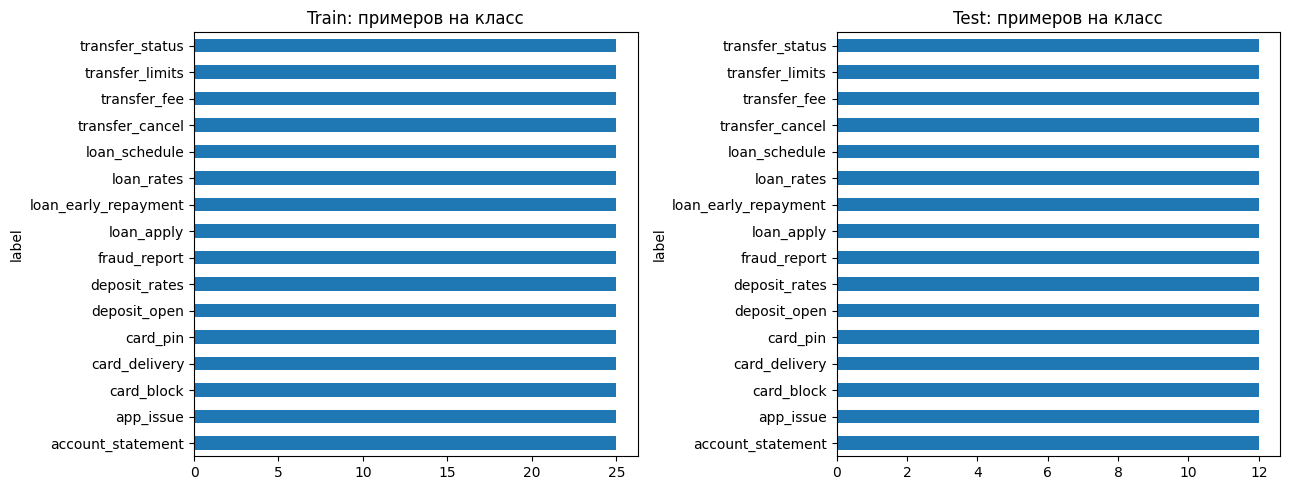

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
train_df.label.value_counts().sort_index().plot(kind="barh", ax=ax[0], title="Train: примеров на класс")
test_df.label.value_counts().sort_index().plot(kind="barh", ax=ax[1], title="Test: примеров на класс")
plt.tight_layout()

# доля «контекстных» диалогов — последняя реплика короткая и без контекста непонятна
short = train_df.dialog.map(lambda d: len(last_msg(d)) < 45).mean()
print(f"Доля диалогов с короткой последней репликой (нужен контекст): {short:.0%}")

## 1.7 Освобождение видеопамяти



In [15]:
for name in ("gen_model", "gen_tok", "llm"):
    globals().pop(name, None)
gc.collect()
torch.cuda.empty_cache()
print(f"Занято видеопамяти: {torch.cuda.memory_allocated() / 1e9:.2f} ГБ")

INFO 09-10 19:41:00 [utils.py:620] [shutdown] Process manager: send sigterm to process EngineCore
WARNING 09-10 19:41:05 [utils.py:640] [shutdown] Process manager: force killing remaining processes count=1
WARNING 09-10 19:41:05 [utils.py:645] [shutdown] Process manager: force killing remaining process EngineCore pid 8407
Занято видеопамяти: 0.00 ГБ


# Часть 2. Классификатор

Классифицируем **весь диалог**, а не только последнюю реплику: в модель подаётся склеенный
текст диалога, а при превышении длины обрезается его **начало** (`truncation_side="left"`),
чтобы последняя реплика клиента гарантированно оставалась на входе.

Основная модель — `cointegrated/rubert-tiny2` (быстрая, хорошо ведёт себя на малых данных),
для сравнения — `ruBert-base`.

In [16]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding)
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

train_df = pd.DataFrame(json.load(open("train.json", encoding="utf-8")))
test_df  = pd.DataFrame(json.load(open("test.json",  encoding="utf-8")))

labels   = sorted(train_df.label.unique())
label2id = {l: i for i, l in enumerate(labels)}
id2label = {i: l for l, i in label2id.items()}
MAX_LEN  = 256

print(len(labels), "классов |", len(train_df), "train |", len(test_df), "test")

16 классов | 400 train | 192 test


In [19]:
def make_ds(tok, df, text_col):
    d = Dataset.from_pandas(pd.DataFrame({"text": df[text_col].tolist(),
                                          "labels": [label2id[l] for l in df.label]}))
    d = d.map(lambda b: tok(b["text"], truncation=True, max_length=MAX_LEN), batched=True)
    return d.remove_columns(["text"])


def run_classifier(model_name, train_df, test_df, lr, epochs, tag, text_col="dialog"):
    tok = AutoTokenizer.from_pretrained(model_name)
    tok.truncation_side = "left"
    train_ds, test_ds = make_ds(tok, train_df, text_col), make_ds(tok, test_df, text_col)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=len(labels), id2label=id2label, label2id=label2id)

    args = TrainingArguments(output_dir=f"out_{tag}", num_train_epochs=epochs, learning_rate=lr,
                             per_device_train_batch_size=16, per_device_eval_batch_size=64,
                             logging_steps=10, save_strategy="no",
                             report_to="none", seed=SEED)
    trainer = Trainer(model=model, args=args, train_dataset=train_ds,
                      data_collator=DataCollatorWithPadding(tok))
    trainer.train()

    pred = trainer.predict(test_ds)
    y_pred, y_true = pred.predictions.argmax(-1), pred.label_ids
    res = {"tag": tag, "accuracy": accuracy_score(y_true, y_pred),
           "macro_f1": f1_score(y_true, y_pred, average="macro"),
           "y_true": y_true, "y_pred": y_pred, "trainer": trainer, "tok": tok, "model": model}
    print(f"[{tag}] accuracy = {res['accuracy']:.3f}   macro-F1 = {res['macro_f1']:.3f}")
    return res


results = []

## 2.1 rubert-tiny2 на полном диалоге

In [22]:
main = run_classifier("cointegrated/rubert-tiny2", train_df, test_df, lr=5e-5, epochs=20, tag="rubert-tiny2, диалог")
results.append(main)
print()
print(classification_report(main["y_true"], main["y_pred"], target_names=labels, digits=3))

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/192 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
10,2.770722
20,2.744279
30,2.699533
40,2.603657
50,2.527774
60,2.408372
70,2.293476
80,2.184281
90,2.043058
100,2.009429


[rubert-tiny2, диалог] accuracy = 0.943   macro-F1 = 0.942

                      precision    recall  f1-score   support

   account_statement      0.909     0.833     0.870        12
           app_issue      0.917     0.917     0.917        12
          card_block      1.000     1.000     1.000        12
       card_delivery      1.000     1.000     1.000        12
            card_pin      0.917     0.917     0.917        12
        deposit_open      0.846     0.917     0.880        12
       deposit_rates      0.909     0.833     0.870        12
        fraud_report      1.000     0.917     0.957        12
          loan_apply      0.923     1.000     0.960        12
loan_early_repayment      1.000     1.000     1.000        12
          loan_rates      1.000     1.000     1.000        12
       loan_schedule      0.857     1.000     0.923        12
     transfer_cancel      1.000     0.750     0.857        12
        transfer_fee      1.000     1.000     1.000        12
     tran

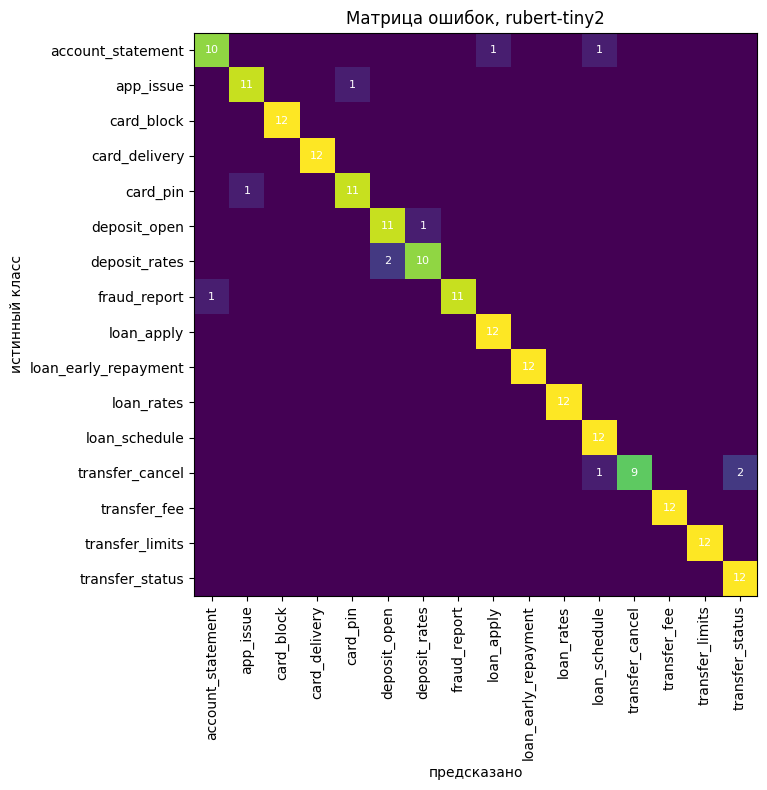

In [23]:
cm = confusion_matrix(main["y_true"], main["y_pred"])
fig, ax = plt.subplots(figsize=(9, 8))
ax.imshow(cm)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=90)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xlabel("предсказано"); ax.set_ylabel("истинный класс"); ax.set_title("Матрица ошибок, rubert-tiny2")
for i in range(len(labels)):
    for j in range(len(labels)):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha="center", va="center", color="w", fontsize=8)
plt.tight_layout()

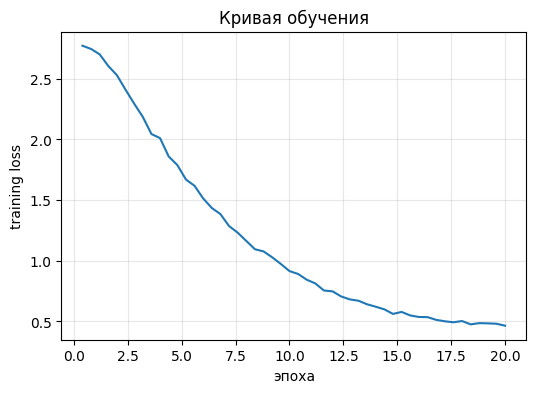

In [24]:
hist = [h for h in main["trainer"].state.log_history if "loss" in h]
plt.figure(figsize=(6, 4))
plt.plot([h["epoch"] for h in hist], [h["loss"] for h in hist])
plt.xlabel("эпоха"); plt.ylabel("training loss"); plt.title("Кривая обучения"); plt.grid(alpha=.3)

## 2.2 ruBert-base

In [25]:
if RUN_RUBERT_BASE:
    base = run_classifier("ai-forever/ruBert-base", train_df, test_df, lr=2e-5, epochs=8, tag="ruBert-base, диалог")
    results.append(base)

config.json:   0%|          | 0.00/590 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.78M [00:00<?, ?B/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/192 [00:00<?, ? examples/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  716MB            

...

[transformers] BertForSequenceClassification LOAD REPORT from: ai-forever/ruBert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params we

model.safetensors: reconstructing file:   0%|          |  0.00B /  716MB            

model.safetensors: downloading bytes:           |  0.00B            

Step,Training Loss
10,2.763609
20,2.633322
30,2.412214
40,2.191467
50,1.936167
60,1.698388
70,1.461207
80,1.293056
90,1.090940
100,1.019623


[ruBert-base, диалог] accuracy = 0.964   macro-F1 = 0.963


## 2.3 Бейзлайн: TF-IDF + логистическая регрессия

Проверка, что трансформер действительно нужен. Если TF-IDF почти не отстаёт — значит, задача
решается по ключевым словам и датасет слишком простой.

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

baseline = make_pipeline(TfidfVectorizer(ngram_range=(1, 2), min_df=2), LogisticRegression(max_iter=2000))
baseline.fit(train_df.dialog, train_df.label)
bl_pred = baseline.predict(test_df.dialog)

results.append({"tag": "TF-IDF + LogReg, диалог",
                "accuracy": accuracy_score(test_df.label, bl_pred),
                "macro_f1": f1_score(test_df.label, bl_pred, average="macro")})
print(f"[бейзлайн] accuracy = {results[-1]['accuracy']:.3f}   macro-F1 = {results[-1]['macro_f1']:.3f}")

[бейзлайн] accuracy = 0.958   macro-F1 = 0.959


## 2.4 Нужен ли контекст?

Проверка по п. 5 задания: обучаем ту же модель только на последней реплике клиента.
Если качество падает — контекст действительно несёт информацию и датасет собран правильно.

In [27]:
train_last = train_df.assign(last=train_df.dialog.map(last_msg))
test_last  = test_df.assign(last=test_df.dialog.map(last_msg))

last_only = run_classifier("cointegrated/rubert-tiny2", train_last, test_last,
                           lr=5e-5, epochs=20, tag="rubert-tiny2, только последняя реплика", text_col="last")
results.append(last_only)
print(f"\nПрирост от контекста: +{main['macro_f1'] - last_only['macro_f1']:.3f} macro-F1")

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/192 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
10,2.772506
20,2.758028
30,2.718690
40,2.694212
50,2.662733
60,2.595448
70,2.565523
80,2.529218
90,2.431046
100,2.417720


[rubert-tiny2, только последняя реплика] accuracy = 0.359   macro-F1 = 0.331

Прирост от контекста: +0.611 macro-F1


In [28]:
bl_last = make_pipeline(TfidfVectorizer(ngram_range=(1, 2), min_df=2), LogisticRegression(max_iter=2000))
bl_last.fit(train_last["last"], train_last.label)
print("TF-IDF только последняя реплика: accuracy =", round(accuracy_score(test_last.label, bl_last.predict(test_last["last"])), 3))

TF-IDF только последняя реплика: accuracy = 0.292


## 2.5 Сводная таблица

In [30]:
summary = pd.DataFrame([{"модель": r["tag"], "accuracy": round(r["accuracy"], 3), "macro-F1": round(r["macro_f1"], 3)}
                        for r in results])
summary.loc[len(summary)] = ["TF-IDF + LogReg, только последняя реплика",
                             round(accuracy_score(test_last.label, bl_last.predict(test_last["last"])), 3),
                             round(f1_score(test_last.label, bl_last.predict(test_last["last"]), average="macro"), 3)]
summary = summary.drop_duplicates("модель").reset_index(drop=True)
summary

,модель,accuracy,macro-F1
0,"rubert-tiny2, диалог",0.943,0.942
1,"ruBert-base, диалог",0.964,0.963
2,"TF-IDF + LogReg, диалог",0.958,0.959
3,"rubert-tiny2, только последняя реплика",0.359,0.331
4,"TF-IDF + LogReg, только последняя реплика",0.292,0.295


## 2.6 Демонстрация

In [31]:
tok, model = main["tok"], main["model"]

@torch.no_grad()
def predict(dialog, top_k=3):
    enc = tok(dialog, return_tensors="pt", truncation=True, max_length=MAX_LEN).to(model.device)
    probs = model(**enc).logits[0].softmax(-1)
    top = probs.topk(top_k)
    print(dialog)
    print("-" * 60)
    for p, i in zip(top.values.tolist(), top.indices.tolist()):
        print(f"  {id2label[i]:24s} {p:.3f}")
    print("=" * 60)

predict("user: Здравствуйте\n"
        "A: Здравствуйте! Чем можем помочь?\n"
        "user: Я вчера отправил 30 тысяч маме, деньги до сих пор не дошли")

predict("user: хочу взять кредит на 500 тысяч\n"
        "A: Конечно! Кредит наличными можно оформить в приложении, срок до 5 лет.\n"
        "user: а какой процент будет?")

predict("user: добрый день, потерял карту в такси\n"
        "A: Сочувствую. Могу заблокировать карту прямо сейчас, подтверждаете?\n"
        "user: да, давайте")

# одна и та же короткая реплика ("да, давайте") — разные классы в зависимости от контекста
predict("user: хочу открыть вклад на 200 тысяч на год\n"
        "A: Отлично, могу оформить накопительный счёт прямо сейчас, подтверждаете?\n"
        "user: да, давайте")

user: Здравствуйте
A: Здравствуйте! Чем можем помочь?
user: Я вчера отправил 30 тысяч маме, деньги до сих пор не дошли
------------------------------------------------------------
  transfer_status          0.293
  transfer_cancel          0.121
  fraud_report             0.098
user: хочу взять кредит на 500 тысяч
A: Конечно! Кредит наличными можно оформить в приложении, срок до 5 лет.
user: а какой процент будет?
------------------------------------------------------------
  loan_apply               0.493
  loan_rates               0.120
  loan_schedule            0.056
user: добрый день, потерял карту в такси
A: Сочувствую. Могу заблокировать карту прямо сейчас, подтверждаете?
user: да, давайте
------------------------------------------------------------
  card_block               0.645
  fraud_report             0.064
  loan_early_repayment     0.053
user: хочу открыть вклад на 200 тысяч на год
A: Отлично, могу оформить накопительный счёт прямо сейчас, подтверждаете?
user: да, давай